# Pre-trade

In [441]:
# Step 2: Import Python Packages: Pandas, Numpy, and Statistics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
from scipy.optimize import minimize
import os
from scipy.stats import norm


In [442]:
# Step 3: Set I/O Folders
InputPath = 'inputFolder'

os.makedirs('outputFolder', exist_ok=True)
OutputPath = 'outputFolder'

In [443]:
# Step 4: Set MI Parameters - Calculated from Non-Linear Regression Analysis
a1=883.58722
a2=0.35408
a3=0.755684
a4=0.826155
b1=0.963532
MIParams = [a1, a2, a3, a4, b1]
print(MIParams)

[883.58722, 0.35408, 0.755684, 0.826155, 0.963532]


In [444]:
# Step 5: User Defined TCA Pre-Trade Functions

# ----------------- HW 7 --------------------
# Develop Python TCA Pre-Trade functions to calculate:
# Market Impact (MI)
# Timing Risk (TR)
# Price Appreciation (PA)
# POV Rate to Trade Time (PovToTime)
# Trade Time to POV Rate (TimeToPOV)
# Expected Cost (ExpCost)
# Expected Execution Price (ExpPrice)


class PreTradeTCA:
    @staticmethod
    def MarketImpact(Size, POV, Volatility):
        """ Calculate Market Impact (MI) in bps"""
        Istar = a1 * (Size ** a2) * (Volatility ** a3)
        MI = Istar * (b1 * POV ** a4 + (1 - b1))
        return MI
    
    @staticmethod
    def TimingRisk(Size, POV, Volatility):
        """Calculates Timing Risk (TR) in bps """
        TR = Volatility * np.sqrt((1/3) * (1/250) * Size * ((1 - POV)/POV)) * 10000
        return TR
    
    @staticmethod
    def PriceAppreciation(Side, AlphaBp, Size, POV):
        """Calculates Price Appreciation (PA) in bps """
        PA = Side * 0.5 * AlphaBp * Size * ((1 - POV)/POV)
        return PA
    
    @staticmethod
    def PovToTime(Size, POV):
        """Converts POV rate to Trade Time """
        return Size * ((1 - POV) / POV)
    
    def TimeToPOV(Self, Size, TradeTime):
        """Converts Trade Time to POV rate """
        return Size / (Size + TradeTime)
    
    @staticmethod
    def ExpectedCost(MI, PA):
        """Calculates Expected Cost"""
        return MI + PA
    
    @staticmethod
    def ExpectedPrice(P0, Side, MI, PA):
        """Calculates Expected Execution Price """
        return P0 * (1 + (Side * (MI + PA) / 10000))
    

In [445]:
# Step 6: User Defined Optimization Functions

# ----------------- HW 8 --------------------
# Develop Python optimization functions to calculate:
# 1. Traders Dilemma
# 2. Minimize Cost
# 3. Price Improvement
# 4. Efficient Trading Frontier
# 5. Market Impact Constraint

class TradeOptimizer(PreTradeTCA):
    def __init__(self):
        # Inherit all pre-trade functions from PreTradeTCA
        super().__init__()

    # --- 1. Traders Dilemma ---
    def traders_dilemma(self, size, vol, risk_aversion):
        objective = lambda pov: self.MarketImpact(size, pov, vol) + (risk_aversion * self.TimingRisk(size, pov, vol))
        res = minimize(objective, x0=0.15, bounds=[(0.01, 0.99)])
        return res.x[0]

    # --- 2. Minimize Cost (with Alpha) ---
    def minimize_cost(self, side, size, vol, alpha_bp):
        # PA already includes Side logic in your PreTradeTCA class
        objective = lambda pov: self.MarketImpact(size, pov, vol) + self.PriceAppreciation(side, alpha_bp, size, pov)
        res = minimize(objective, x0=0.15, bounds=[(0.01, 0.99)])
        return res.x[0]

    # --- 3. Price Improvement ---
    def price_improvement(self, size, vol, bid_bps):
        # Maximizing (Bid - MI)/TR is equivalent to minimizing (MI - Bid)/TR
        objective = lambda pov: (self.MarketImpact(size, pov, vol) - bid_bps) / self.TimingRisk(size, pov, vol)
        res = minimize(objective, x0=0.15, bounds=[(0.01, 0.99)])
        return res.x[0]


    # --- 5. Market Impact Constraint ---
    def mi_constraint(self, target_mi, vol, time_days=1.0):
        # Solve for Size (S) given MI <= Target and Time = 1 day
        # Since Time = S * (1-POV)/POV, if Time=1, POV = S / (S+1)
        objective = lambda s: abs(self.MarketImpact(s, s/(s+1), vol) - target_mi)
        res = minimize(objective, x0=0.05, bounds=[(0.001, 0.5)])
        return res.x[0]
    

    # --- 1. Traders Dilemma Graph ---
    def solve_traders_dilemma(self, size, vol, lambd):
        objective = lambda pov: self.MarketImpact(size, pov, vol) + (lambd * self.TimingRisk(size, pov, vol))
        res = minimize(objective, x0=0.15, bounds=[(0.01, 0.99)])
        return res.x[0]

    def plot_traders_dilemma(self, size, vol, lambd):
        # We vary POV to generate curves, then map to Time
        pov_range = np.linspace(0.01, 0.8, 120)
        times = [self.PovToTime(size, p) for p in pov_range]
        mi_vals = [self.MarketImpact(size, p, vol) for p in pov_range]
        tr_vals = [lambd * self.TimingRisk(size, p, vol) for p in pov_range]
        total = [m + t for m, t in zip(mi_vals, tr_vals)]
        
        # Calculate optimal point
        opt_pov = self.solve_traders_dilemma(size, vol, lambd)
        opt_time = self.PovToTime(size, opt_pov)
        # Calculate the minimum value of the objective function
        opt_cost = self.MarketImpact(size, opt_pov, vol) + (lambd * self.TimingRisk(size, opt_pov, vol))
        
        plt.figure(figsize=(10, 6))
        
        # Plotting curves
        plt.plot(times, mi_vals, color='blue', label='Market Impact (MI)', alpha=0.7)
        plt.plot(times, tr_vals, color='orange', label=f'Timing Risk ($\lambda$*TR)', alpha=0.7)
        plt.plot(times, total, color='green', label='Total Cost (MI + $\lambda$*TR)', linewidth=2.5)
        
        # Mark the Minimum Objective Function Point
        plt.scatter(opt_time, opt_cost, color='red', s=100, zorder=5, label=f'Min Objective: {opt_cost:.2f} bps')
        
        # Add annotation for clarity
        plt.annotate(f'Optimal Cost: {opt_cost:.2f} bps\nat {opt_time:.4f} Days',
                     xy=(opt_time, opt_cost),
                     xytext=(opt_time + 0.2, opt_cost + 10),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

        # Horizontal and Vertical lines to the axes
        plt.axhline(opt_cost, color='black', linestyle='--', alpha=0.6)
        plt.axvline(opt_time, color='black', linestyle='--', alpha=0.6)
        
        plt.xlim(0, 3)
        plt.ylim(0, max(total) * 1.1) # Dynamic scaling for y-axis
        
        plt.title(f"Traders Dilemma: Cost vs. Trade Time\n(Size={size}, Vol={vol}, $\lambda$={lambd})")
        plt.xlabel("Trade Time (Days)")
        plt.ylabel("Cost (bps)")
        plt.legend()
        plt.grid(True, which='both', linestyle='--', alpha=0.5)
        plt.show()

    # --- 2. Trade Cost Distribution (PDF) ---
    def plot_cost_distribution(self, size, pov, vol):
        mi = self.MarketImpact(size, pov, vol)
        tr = self.TimingRisk(size, pov, vol)
        x = np.linspace(mi - 3*tr, mi + 3*tr, 120)
        pdf = norm.pdf(x, mi, tr)
        
        plt.figure(figsize=(8, 5))
        plt.plot(x, pdf, color='blue')
        plt.fill_between(x, pdf, color='blue', alpha=0.2)
        plt.title("Q1: Trade Cost Distribution (PDF)")
        plt.axvline(mi, color='black', linestyle=':', linewidth=2, label=f'Mean (MI): {mi:.2f} bps')
        plt.title("Q1: Trade Cost Distribution (PDF)")
        plt.xlabel("Estimated Cost (bps)"), plt.ylabel("Probability"), plt.legend(), plt.grid(True)
        plt.show()

    # --- 3. Cumulative Distribution (CDF) ---
    def plot_cumulative_distribution(self, size, pov, vol, conf_level=0.5):
        # Calculate base components
        mi = self.MarketImpact(size, pov, vol)
        tr = self.TimingRisk(size, pov, vol)
        
        # Calculate the cost value at the specified confidence level (x-intercept)
        cost_at_conf = norm.ppf(conf_level, mi, tr)
        
        # Set up the range for the x-axis
        x = np.linspace(mi - 4*tr, mi + 4*tr, 200)
        cdf = norm.cdf(x, mi, tr)
        
        plt.figure(figsize=(10, 6))
        plt.plot(x, cdf, color='steelblue', linewidth=2, label='CDF')
        
        # --- Add Dashed Intersection Lines ---
        # Horizontal line to the curve
        plt.axhline(y=conf_level, xmin=0, xmax=(cost_at_conf - x[0])/(x[-1] - x[0]), 
                    color='black', linestyle='--', linewidth=1)
        
        # Vertical line down to the axis
        plt.axvline(x=cost_at_conf, ymin=0, ymax=conf_level, 
                    color='black', linestyle='--', linewidth=1)
        
        # --- Labeling the Values ---
        # Label for the Y-axis value (Confidence Level)
        plt.text(x[0], conf_level + 0.02, f' {conf_level*100:.1f}%', 
                 verticalalignment='bottom', fontweight='bold', color='black')
        
        # Label for the X-axis value (Est. Cost in bps)
        plt.text(cost_at_conf, -0.05, f'{cost_at_conf:.2f} bps', 
                 horizontalalignment='center', fontweight='bold', color='black')

        # Highlight the intersection point
        plt.scatter(cost_at_conf, conf_level, color='red', s=40, zorder=5)

        # Formatting
        plt.title("Cumulative Trade Cost Distribution (CDF)")
        plt.xlabel("Est. Cost (bps)")
        plt.ylabel("CDF (Confidence Level)")
        plt.xlim(x[0], x[-1])
        plt.ylim(0, 1.05)
        plt.grid(False) 
        plt.show()

    # --- 4. Price Improvement Strategy ---
    def plot_price_improvement(self, size, vol, bid_bps):
        pov_range = np.linspace(0.01, 0.9, 100)
        times = [self.PovToTime(size, p) for p in pov_range]
        # Objective is (Bid - MI) / TR
        obj_vals = [(bid_bps - self.MarketImpact(size, p, vol)) / self.TimingRisk(size, p, vol) for p in pov_range]
        
        # Calculate the optimal point using your existing price_improvement solver
        opt_pov = self.price_improvement(size, vol, bid_bps)
        opt_time = self.PovToTime(size, opt_pov)
        
        # Calculate the maximum objective value at that point
        opt_obj = (bid_bps - self.MarketImpact(size, opt_pov, vol)) / self.TimingRisk(size, opt_pov, vol)
        
        plt.figure(figsize=(10, 6))
        plt.plot(times, obj_vals, color='green', linewidth=2, label='Objective Function')
        
        # Mark the Maximum Point
        plt.scatter(opt_time, opt_obj, color='red', s=100, zorder=5, label=f'Max Obj: {opt_obj:.4f}')
        
        # Add annotation
        plt.annotate(f'Max Objective: {opt_obj:.4f}\nat {opt_time:.4f} Days',
                     xy=(opt_time, opt_obj),
                     xytext=(opt_time + 0.3, opt_obj),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))
        
        # Horizontal and Vertical dashed lines for the maximum point
        plt.axhline(opt_obj, color='gray', linestyle='--', alpha=0.6)
        plt.axvline(opt_time, color='gray', linestyle='--', alpha=0.6)

        plt.title(f"Q3: Price Improvement Strategy (Bid={bid_bps}bps)")
        plt.xlabel("Trade Time (Days)")
        plt.ylabel("t- Value (Objective Function: (Bid - MI) / TR)")
        plt.legend()
        plt.grid(True, which='both', linestyle='--', alpha=0.5)
        plt.show()

    # --- 5. Efficient Trading Frontier ---
    def plot_efficient_frontier(self, size, vol):
        lambdas = np.linspace(0.05, 3.0, 40)
        mi_pts, tr_pts = [], []
        for l in lambdas:
            p = self.traders_dilemma(size, vol, l)
            mi_pts.append(self.MarketImpact(size, p, vol))
            tr_pts.append(self.TimingRisk(size, p, vol))
            
        plt.figure(figsize=(8, 5))
        plt.plot(tr_pts, mi_pts, 'o-', markersize=4, color='blue')
        plt.xlabel("Timing Risk (TR)"), plt.ylabel("Market Impact (MI)"), plt.grid(True)
        plt.show()

    # --- 6. MI Cost as a Function of Shares ---
    def plot_mi_vs_shares(self, vol, ADV, target_mi, target_time=1.0):
        # Generate a range of sizes to cover the constraint point
        sizes = np.linspace(0.001, 0.5, 100)
        shares_range = sizes * ADV
        
        # Calculate MI for each size at the fixed target time
        mi_vals = [self.MarketImpact(s, self.TimeToPOV(s, target_time), vol) for s in sizes]
        
        # Solve for the exact size matching the target MI
        opt_size = self.mi_constraint(target_mi, vol, target_time)
        opt_shares = opt_size * ADV
        
        plt.figure(figsize=(8, 5))
        plt.plot(shares_range, mi_vals, color='steelblue', label='MI Cost', linewidth=2)
        
        # --- Add Dashed Intersection Lines ---
        # Horizontal line to the MI Constraint
        plt.axhline(y=target_mi, xmin=0, xmax=opt_shares/max(shares_range), 
                    color='black', linestyle='--', linewidth=1)
        
        # Vertical line down to the Shares axis
        plt.axvline(x=opt_shares, ymin=0, ymax=target_mi/max(mi_vals), 
                    color='black', linestyle='--', linewidth=1)
        
        # Red dot at the intersection
        plt.scatter(opt_shares, target_mi, color='red', s=50, zorder=5)
        
        # --- Add Annotation and Values ---
        plt.annotate(f'Max MI (MI Constraint)\nShares: {opt_shares:,.0f}\nMI: {target_mi:.2f}',
                     xy=(opt_shares, target_mi),
                     xytext=(opt_shares + (0.05 * ADV), target_mi - 10),
                     arrowprops=dict(facecolor='black', arrowstyle='->'))

        # Labels and Formatting to match the homework style
        plt.title("MI Cost as a function of Shares")
        plt.xlabel("Shares")
        plt.ylabel("MI Cost")
        plt.xlim(0, max(shares_range))
        plt.ylim(0, max(mi_vals))
        plt.grid(False) # Reference image has a clean background
        plt.legend(loc='upper left')
        plt.show()



<>:70: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:71: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:89: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:70: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:71: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:89: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/h0/s41cy5xj0qx08m983bv4kc3c0000gn/T/ipykernel_1497/3545585984.p

In [446]:
# Initialize TCA and Optimization Classes
tca = PreTradeTCA()
opt = TradeOptimizer()

# --------------------------------------
# Homework 7
# --------------------------------------

## Pre-Trade Calculations

### Question 1

In [447]:
Side = 1
Size = 0.10
Volatility = 0.35
AlphaBp = 30
POV = 0.20

MI = tca.MarketImpact(Size=Size, POV=POV, Volatility=Volatility)
TR = tca.TimingRisk(Size=Size, POV=POV, Volatility=Volatility)
PA = tca.PriceAppreciation(Side=Side, AlphaBp=AlphaBp, Size=Size, POV=POV)
PovToTime = tca.PovToTime(Size=Size, POV=POV)

print(f'Market Impact: {MI:.4f} bps')
print(f'Timing Risk: {TR:.4f} bps')
print(f'Price Appreciation: {PA:.4f} bps')
print(f'POV : {POV * 100:.4f}%')
print(f'Trade Time: {PovToTime:.4f}')


Market Impact: 51.5353 bps
Timing Risk: 80.8290 bps
Price Appreciation: 6.0000 bps
POV : 20.0000%
Trade Time: 0.4000


### Question 2

In [448]:
Side = -1
Size = 125_000 / 1_000_000
Volatility = 0.40
AlphaBp = 10
POV = 0.10

MI = tca.MarketImpact(Size=Size, POV=POV, Volatility=Volatility)
TR = tca.TimingRisk(Size=Size, POV=POV, Volatility=Volatility)
PA = tca.PriceAppreciation(Side=Side, AlphaBp=AlphaBp, Size=Size, POV=POV)
PovToTime = tca.PovToTime(Size=Size, POV=POV)

print(f'Market Impact: {MI:.4f} bps')
print(f'Timing Risk: {TR:.4f} bps')
print(f'Price Appreciation: {PA:.4f} bps')
print(f'POV : {POV * 100:.4f}%')
print(f'Trade Time: {PovToTime:.4f}')

Market Impact: 38.1634 bps
Timing Risk: 154.9193 bps
Price Appreciation: -5.6250 bps
POV : 10.0000%
Trade Time: 1.1250


## Expected Cost and Expected Price

### Question 3

In [449]:
Side = 1
Size = 0.05
Volatility = 0.25
AlphaBp = 10
Price = 75
TradeTime = 1

POV = tca.TimeToPOV(Size=Size, TradeTime=TradeTime)
TradeTime = tca.PovToTime(Size=Size, POV=POV)
MI = tca.MarketImpact(Size=Size, POV=POV, Volatility=Volatility)
TR = tca.TimingRisk(Size=Size, POV=POV, Volatility=Volatility)
PA = tca.PriceAppreciation(Side=Side, AlphaBp=AlphaBp, Size=Size, POV=POV)
ExpectedCost = tca.ExpectedCost(MI=MI, PA=PA)
ExpectedPrice = tca.ExpectedPrice(P0=Price, Side=Side, MI=MI, PA=PA)

print(f'Market Impact: {MI:.4f} bps')
print(f'Timing Risk: {TR:.4f} bps')
print(f'Price Appreciation: {PA:.4f} bps')
print(f'POV : {POV * 100:.4f}%')
print(f'Trade Time: {TradeTime:.4f}')
print(f'Expected Cost: {ExpectedCost:.4f} bps')
print(f'Expected Price: {ExpectedPrice:.4f}')


Market Impact: 12.2715 bps
Timing Risk: 91.2871 bps
Price Appreciation: 5.0000 bps
POV : 4.7619%
Trade Time: 1.0000
Expected Cost: 17.2715 bps
Expected Price: 75.1295


### Question 4

In [450]:
Side = -1
Size = 75_000 / 650_000
Volatility = 0.30
AlphaBp = -10
Price = 250
TradeTime = 0.5

POV = tca.TimeToPOV(Size=Size, TradeTime=TradeTime)
TradeTime = tca.PovToTime(Size=Size, POV=POV)
MI = tca.MarketImpact(Size=Size, POV=POV, Volatility=Volatility)
TR = tca.TimingRisk(Size=Size, POV=POV, Volatility=Volatility)
PA = tca.PriceAppreciation(Side=Side, AlphaBp=AlphaBp, Size=Size, POV=POV)
ExpectedCost = tca.ExpectedCost(MI=MI, PA=PA)
ExpectedPrice = tca.ExpectedPrice(P0=Price, Side=Side, MI=MI, PA=PA)

print(f'Market Impact: {MI:.4f} bps')
print(f'Timing Risk: {TR:.4f} bps')
print(f'Price Appreciation: {PA:.4f} bps')
print(f'POV : {POV * 100:.4f}%')
print(f'Trade Time: {TradeTime:.4f}')
print(f'Expected Cost: {ExpectedCost:.4f} bps')
print(f'Expected Price: {ExpectedPrice:.5f}')

Market Impact: 46.0606 bps
Timing Risk: 77.4597 bps
Price Appreciation: 2.5000 bps
POV : 18.7500%
Trade Time: 0.5000
Expected Cost: 48.5606 bps
Expected Price: 248.78598


### Question 5

In [451]:
Side = 1
Size = 115_250 / 800_000
Volatility = 0.50
AlphaBp = -5
Price = 100
TradeTime = 0.75

POV = tca.TimeToPOV(Size=Size, TradeTime=TradeTime)
TradeTime = tca.PovToTime(Size=Size, POV=POV)
MI = tca.MarketImpact(Size=Size, POV=POV, Volatility=Volatility)
TR = tca.TimingRisk(Size=Size, POV=POV, Volatility=Volatility)
PA = tca.PriceAppreciation(Side=Side, AlphaBp=AlphaBp, Size=Size, POV=POV)
ExpectedCost = tca.ExpectedCost(MI=MI, PA=PA)
ExpectedPrice = tca.ExpectedPrice(P0=Price, Side=Side, MI=MI, PA=PA)

print(f'Market Impact: {MI:.4f} bps')
print(f'Timing Risk: {TR:.4f} bps')
print(f'Price Appreciation: {PA:.4f} bps')
print(f'POV : {POV * 100:.4f}%')
print(f'Trade Time: {TradeTime:.4f}')
print(f'Expected Cost: {ExpectedCost:.4f} bps')
print(f'Expected Price: {ExpectedPrice:.5f}')

Market Impact: 65.8059 bps
Timing Risk: 158.1139 bps
Price Appreciation: -1.8750 bps
POV : 16.1132%
Trade Time: 0.7500
Expected Cost: 63.9309 bps
Expected Price: 100.63931


### Question 6

In [452]:
Side = 1
Size = 100_000 / 2_000_000
Volatility = 0.40
AlphaBp = 0
Price = 100
POV = 0.25

TradeTime = tca.PovToTime(Size=Size, POV=POV)
POV = tca.TimeToPOV(Size=Size, TradeTime=TradeTime)
MI = tca.MarketImpact(Size=Size, POV=POV, Volatility=Volatility)
TR = tca.TimingRisk(Size=Size, POV=POV, Volatility=Volatility)
PA = tca.PriceAppreciation(Side=Side, AlphaBp=AlphaBp, Size=Size, POV=POV)
ExpectedCost = tca.ExpectedCost(MI=MI, PA=PA)
ExpectedPrice = tca.ExpectedPrice(P0=Price, Side=Side, MI=MI, PA=PA)

print(f'Market Impact: {MI:.4f} bps')
print(f'Timing Risk: {TR:.4f} bps')
print(f'Price Appreciation: {PA:.4f} bps')
print(f'POV : {POV * 100:.4f}%')
print(f'Trade Time: {TradeTime:.4f}')
print(f'Expected Cost: {ExpectedCost:.4f} bps')
print(f'Expected Price: {ExpectedPrice:.5f}')

Market Impact: 52.4993 bps
Timing Risk: 56.5685 bps
Price Appreciation: 0.0000 bps
POV : 25.0000%
Trade Time: 0.1500
Expected Cost: 52.4993 bps
Expected Price: 100.52499


## Trade Time

### Question 7

In [453]:
Size = 0.25
POV = 0.10

TradeTime = tca.PovToTime(Size=Size, POV=POV)

print(f'Trade Time: {TradeTime:.4f}')

Trade Time: 2.2500


## POV Rate

### Question 8

In [454]:
Size = 0.20
TradeTime = 0.75

POV = tca.TimeToPOV(Size=Size, TradeTime=TradeTime)

print(f'POV : {POV * 100:.4f}%')

POV : 21.0526%


## Maximum Shares

### Question 9

In [455]:
Volatility = 0.50
ADV = 200_000_000
TradeTime = 1
TargetMI = 75
tolerance = 0.0001


# for shares in range(ADV):
#     Size = shares / ADV
#     POV = tca.TimeToPOV(Size=Size, TradeTime=TradeTime)
#     MI = tca.MarketImpact(Size=Size, POV=POV, Volatility=Volatility)

#     if abs(MI - TargetMI) < tolerance:
#         print(f'Shares: {shares:,}')
#         print(f'Market Impact: {MI:.4f} bps')
#         print(f'Size: {Size * 100:.4f}%')
#         # print(f'POV : {POV * 100:.4f}%')
#         break

# ------- Binary Search Implementation -------
# Binary search is significantly faster if ADV is large

l,r = 0, ADV

while l <= r:
    mid = (l + r) // 2
    Size = mid / ADV
    POV = tca.TimeToPOV(Size=Size, TradeTime=TradeTime)
    MI = tca.MarketImpact(Size=Size, POV=POV, Volatility=Volatility)

    if abs(MI - TargetMI) < tolerance:
        print(f'Shares: {mid:,}')
        print(f'Market Impact: {MI:.4f} bps')
        print(f'Size: {Size * 100:.4f}%')
        # print(f'POV : {POV * 100:.4f}%')
        break
    elif MI < TargetMI:
        l = mid + 1
    else:
        r = mid - 1

Shares: 39,609,907
Market Impact: 75.0000 bps
Size: 19.8050%


## Trade Time from AlphaBp

### Question 10

In [456]:
P0 = 65
AlphaBp = 100
targetPrice = 65.45

# Calculate the total return required to reach the target
priceChange  = ((targetPrice / P0) - 1)

# Solve for t: required_return = alpha_decimal * t
time_in_days = priceChange  / (AlphaBp / 10000)

print(f'Time in days: {time_in_days:.5f} days')

Time in days: 0.69231 days


# --------------------------------------
# Homework 8
# --------------------------------------

## Traders Dilemma

### Question 1

Optimal POV: 13.626% | MI: 30.465 | TR: 72.681 | Time: 0.6339


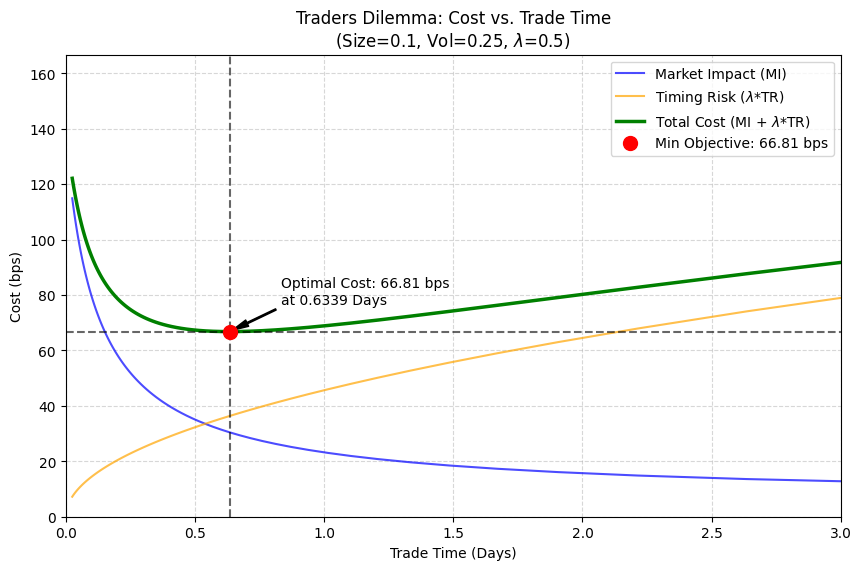

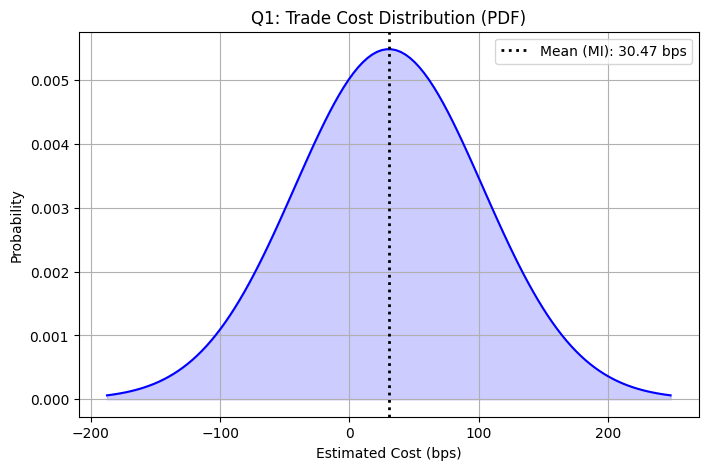

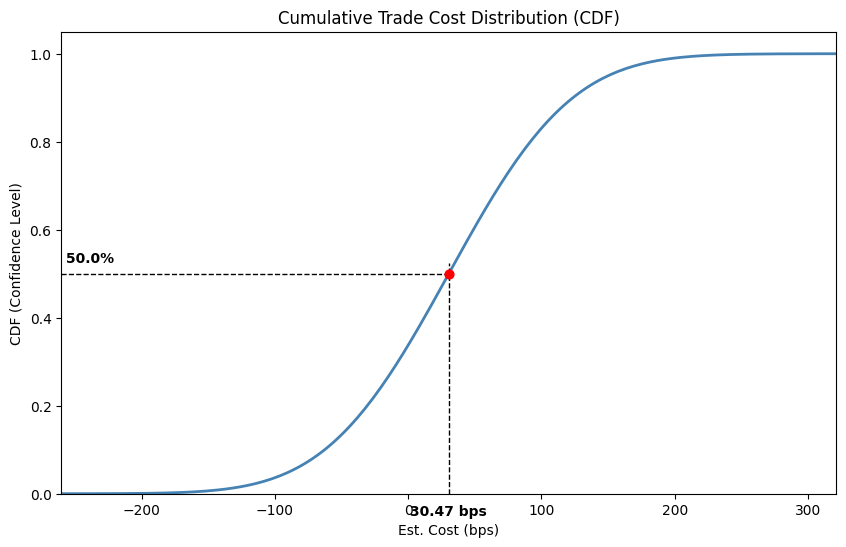

In [457]:
side = 1
size = 0.10
volatility = 0.25
risk_aversion = 0.5

q1_pov = opt.traders_dilemma(size=size, vol=volatility, risk_aversion=risk_aversion)
q1_mi = opt.MarketImpact(size, q1_pov, volatility)
q1_tr = opt.TimingRisk(size, q1_pov, volatility)
q1_time = opt.PovToTime(size, q1_pov)

print(f"Optimal POV: {q1_pov*100:.3f}% | MI: {q1_mi:.3f} | TR: {q1_tr:.3f} | Time: {q1_time:.4f}")

opt.plot_traders_dilemma(size=size, vol=volatility, lambd=risk_aversion)
opt.plot_cost_distribution(size=size, pov=q1_pov, vol=volatility)
opt.plot_cumulative_distribution(size=size, pov=q1_pov, vol=0.25)

## Minimize Cost

### Question 2

Optimal POV: 12.643% | MI: 28.937 | PA: 17.275| TR: 75.883 | Time: 0.6910


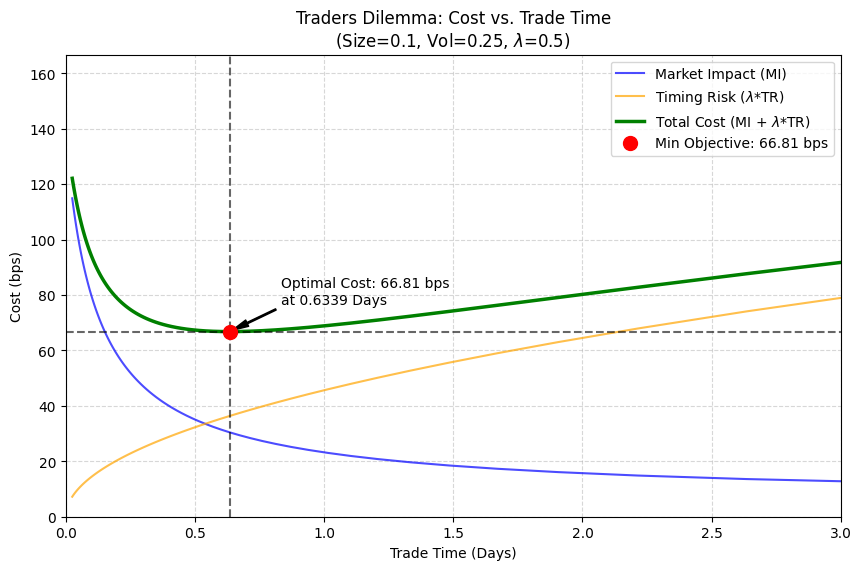

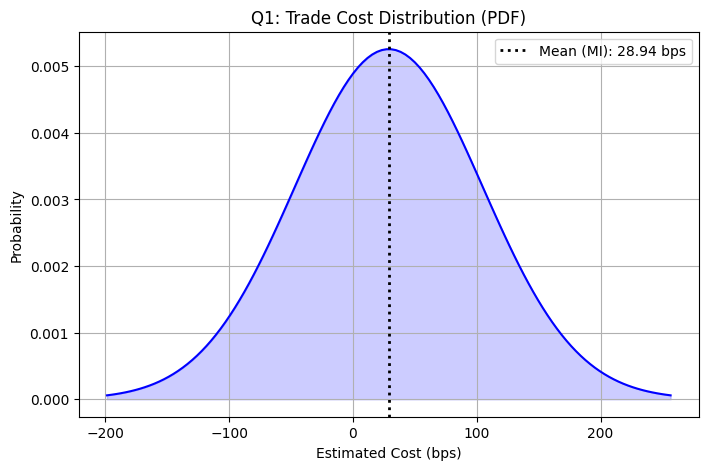

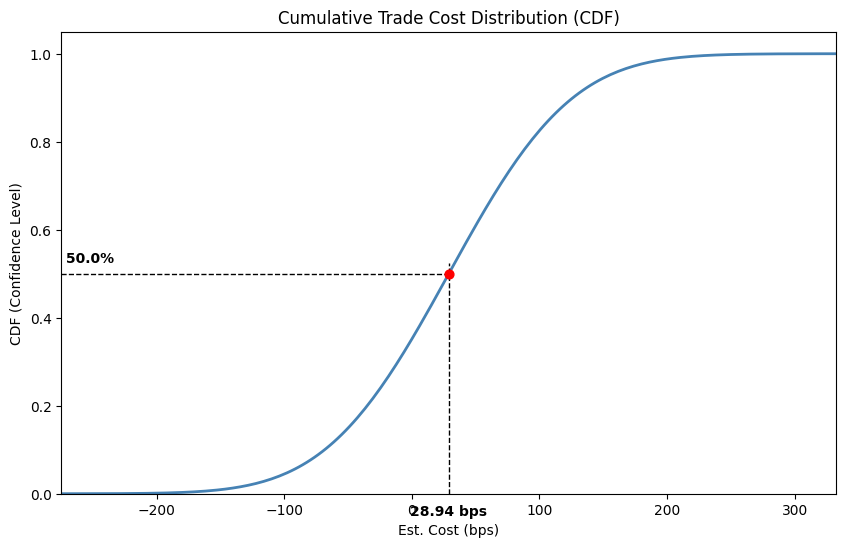

In [467]:
side = 1
size = 0.10
volatility = 0.25
AlphaBp = 100

# MI + PA optimization
# pov = opt.minimize_cost(side=side, size=size, vol=volatility, alpha_bp=AlphaBp)

# MI + 0.5*PA to match the homework question
pov = opt.minimize_cost(side=side, size=size, vol=volatility, alpha_bp=AlphaBp/2)

# MI, TR, 
mi = opt.MarketImpact(size, pov, volatility)
tr = opt.TimingRisk(size, pov, volatility)
pa = opt.PriceAppreciation(side, AlphaBp, size, pov) / 2
time = opt.PovToTime(size, pov)

print(f"Optimal POV: {pov*100:.3f}% | MI: {mi:.3f} | PA: {pa:.3f}| TR: {tr:.3f} | Time: {time:.4f}")

opt.plot_traders_dilemma(size=size, vol=volatility, lambd= 0.5)
opt.plot_cost_distribution(size=size, pov=pov, vol=volatility)
opt.plot_cumulative_distribution(size=size, pov=pov, vol=volatility)


## Price Improvement

### Question 3

Optimal POV: 25.357% | MI: 47.538 | TR: 49.528 | POV: 0.2536| Time: 0.2944


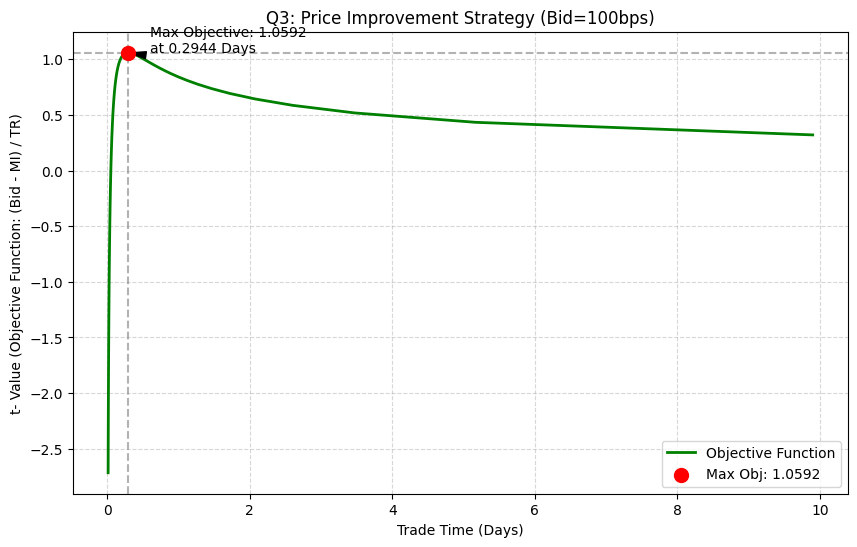

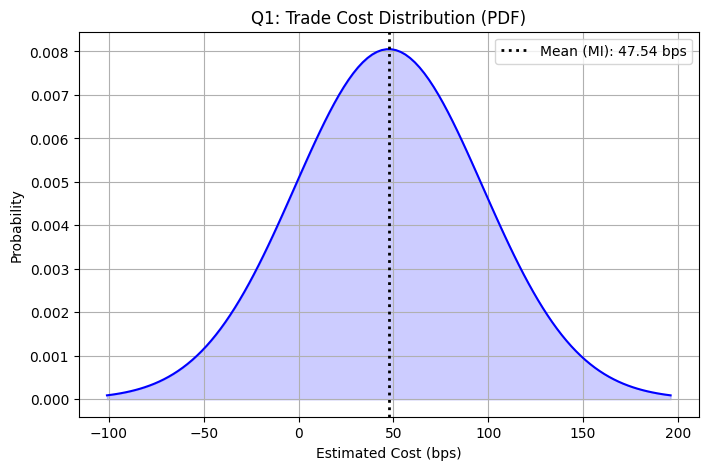

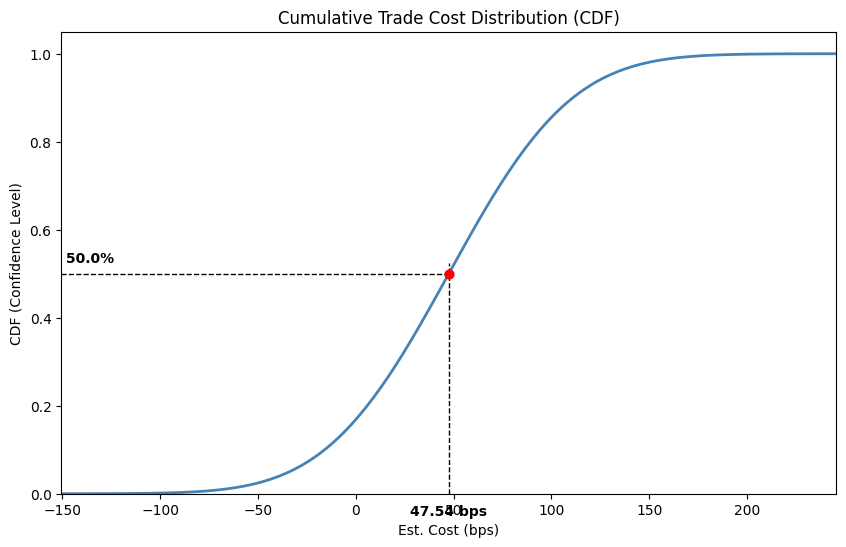

In [459]:
side = 1
size = 0.10
volatility = 0.25
bid = 100

# MI + PA optimization
pov = opt.price_improvement(size=size, vol=volatility, bid_bps=bid)

# MI, TR, Time
mi = opt.MarketImpact(size, pov, volatility)
tr = opt.TimingRisk(size, pov, volatility)
time = opt.PovToTime(size, pov)

print(f"Optimal POV: {pov*100:.3f}% | MI: {mi:.3f} | TR: {tr:.3f} | POV: {pov:.4f}| Time: {time:.4f}")

opt.plot_price_improvement(size=size, vol=volatility, bid_bps=bid)
opt.plot_cost_distribution(size=size, pov=pov, vol=volatility)
opt.plot_cumulative_distribution(size=size, pov=pov, vol=volatility)

## Efficient Trading Frontier

### Question 4

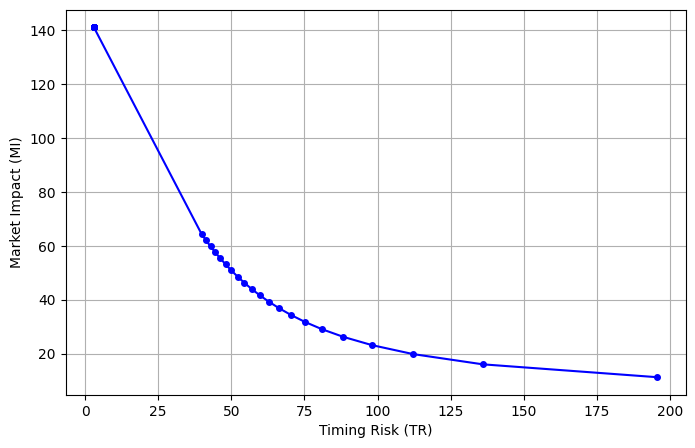

In [460]:
side = 1
shares = 150_000
ADV = 2_000_000
size = shares / ADV
volatility = 0.30
AlphaBp = 0

mi = opt.mi_constraint(target_mi=75, vol=volatility, time_days=1.0)
tr = opt.TimingRisk(size, opt.TimeToPOV(size, 1.0), volatility)

opt.plot_efficient_frontier(size=size, vol=volatility)


## Market Impact Constraint

### Question 5

MI: 50.000| Shares: 449,120


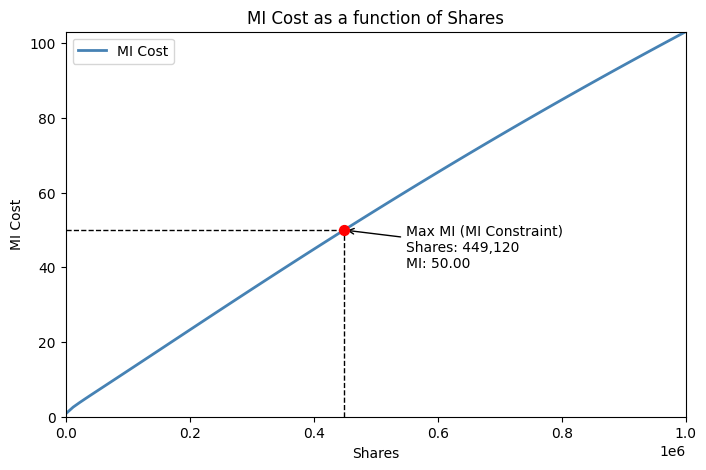

In [461]:
# Parameters for Q5
maxMI = 50
ADV = 2_000_000
volatility = 0.25
time_days = 1.0

# Calculate exact values
opt_size = opt.mi_constraint(target_mi=maxMI, vol=volatility, time_days=time_days)
shares = opt_size * ADV

mi = opt.MarketImpact(opt_size, opt.TimeToPOV(opt_size, time_days), volatility)

print(f"MI: {mi:.3f}| Shares: {shares:,.0f}")

# Generate the plot matching your uploaded image
opt.plot_mi_vs_shares(vol=volatility, ADV=ADV, target_mi=maxMI, target_time=time_days)